In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('C:\\Users\\jeeva\\Downloads\\New folder\\internship\\Online Retail.xlsx') 

In [4]:
df.shape
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.dropna(subset=['CustomerID'], inplace=True)

In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

0

In [10]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,401604.000000,401604.000000
mean,12.183273,3.474064
std,250.283037,69.764035
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


In [11]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

Quantity <= 0: 8872
UnitPrice <= 0: 40


In [12]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [13]:
print("Rows after cleaning:", df.shape[0])
print("Negative/zero Quantity:", (df['Quantity'] <= 0).sum())
print("Zero/negative UnitPrice:", (df['UnitPrice'] <= 0).sum())

Rows after cleaning: 392692
Negative/zero Quantity: 0
Zero/negative UnitPrice: 0


In [14]:
df['Total_Amount'] = df['Quantity'] * df['UnitPrice']

In [15]:
print(df[['Quantity', 'UnitPrice', 'Total_Amount']].head())

   Quantity  UnitPrice  Total_Amount
0         6       2.55         15.30
1         6       3.39         20.34
2         8       2.75         22.00
3         6       3.39         20.34
4         6       3.39         20.34


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df['InvoiceDate'].dtypes

dtype('<M8[ns]')

In [18]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [19]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [20]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total_Amount': 'sum'
})

In [21]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Total_Amount': 'Monetary'
}, inplace=True)

In [22]:
rfm.index = rfm.index.astype(int)

In [23]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [25]:
rfm.info

<bound method DataFrame.info of             Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40
...             ...        ...       ...
18280           278          1    180.60
18281           181          1     80.82
18282             8          2    178.05
18283             4         16   2045.53
18287            43          3   1837.28

[4338 rows x 3 columns]>

In [26]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [27]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 118.6 KB


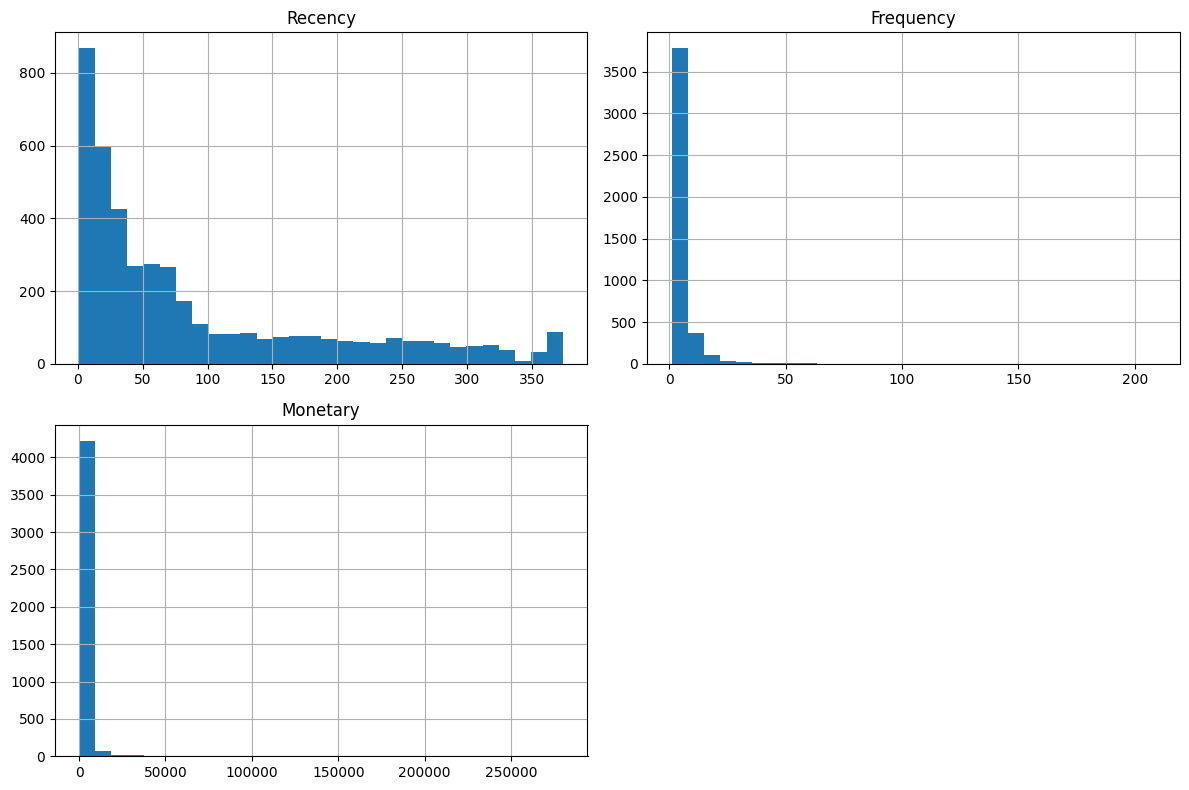

In [31]:

rfm[['Recency', 'Frequency', 'Monetary']].hist(
    bins=30,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [28]:
rfm.skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

In [29]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

In [30]:
rfm_log.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

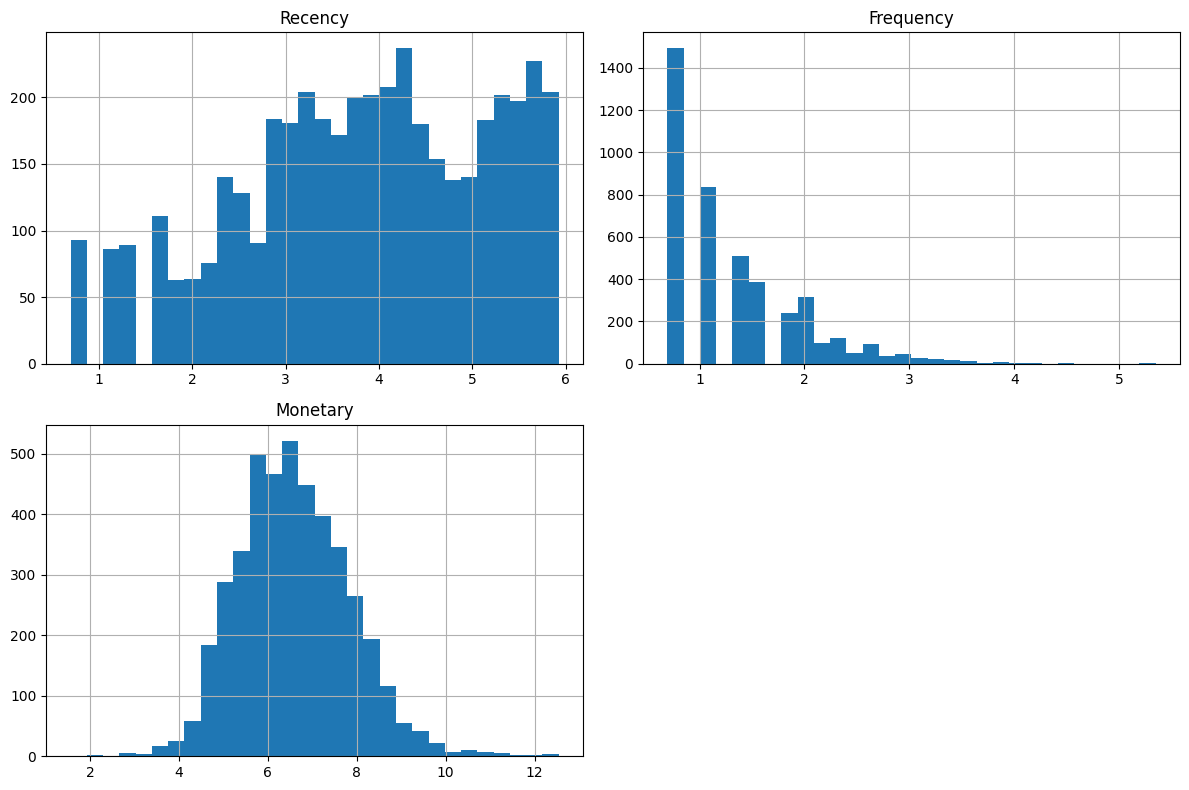

In [35]:

rfm_log[['Recency', 'Frequency', 'Monetary']].hist(
    bins=30,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
rfm_scaled = scaler.fit_transform(rfm_log)

In [34]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

In [35]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.707716
12347,-2.038734,1.074425,1.414903
12348,0.373104,0.386304,0.720024
12349,-0.623086,-0.955214,0.702287
12350,1.424558,-0.955214,-0.614514


In [36]:
rfm_scaled.mean()


Recency     -8.025955e-17
Frequency   -8.189750e-18
Monetary    -3.669008e-16
dtype: float64

In [37]:
rfm_scaled.std()

Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64

In [38]:
from sklearn.cluster import KMeans

In [39]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

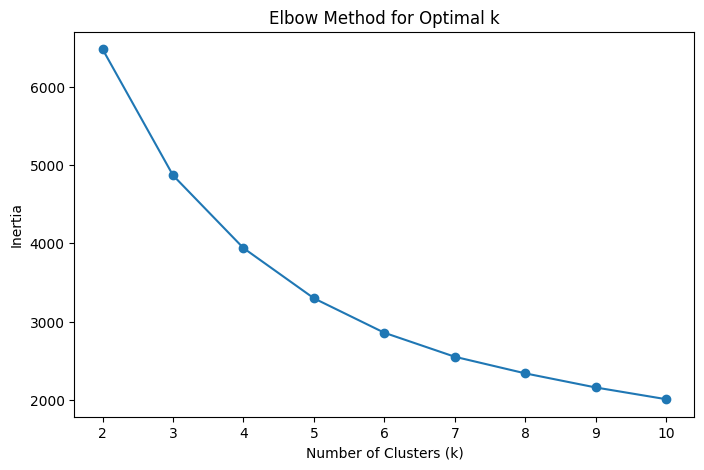

In [40]:
plt.figure(figsize=(8, 5))  
plt.plot(range(2, 11), inertia, marker='o') 
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k') 
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.4328265515350662,
 0.3365174636950013,
 0.33751704921261194,
 0.3162001336222631,
 0.3124091056438892,
 0.30918598433785954,
 0.30327504528060134,
 0.281084500299107,
 0.2766585172543556]

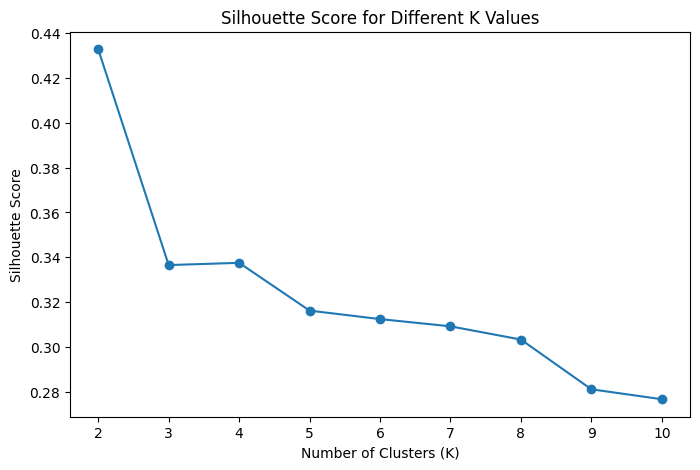

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.show()

In [43]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans_4.fit_predict(rfm_scaled)

In [44]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [45]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


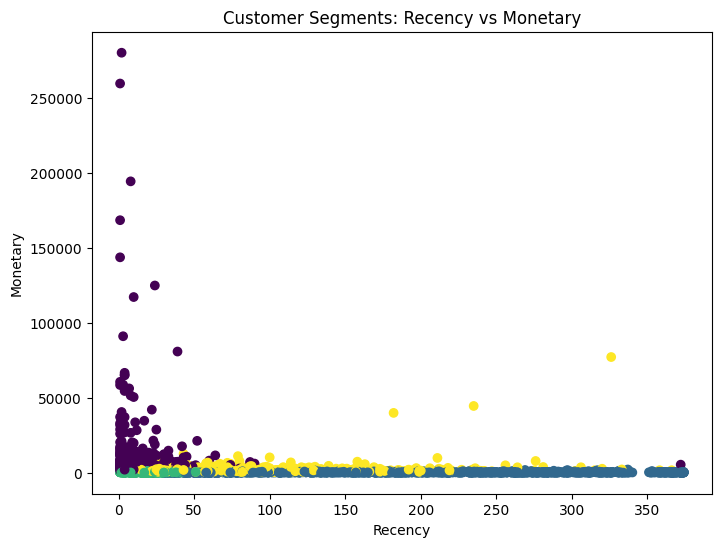

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Recency vs Monetary')

plt.show()

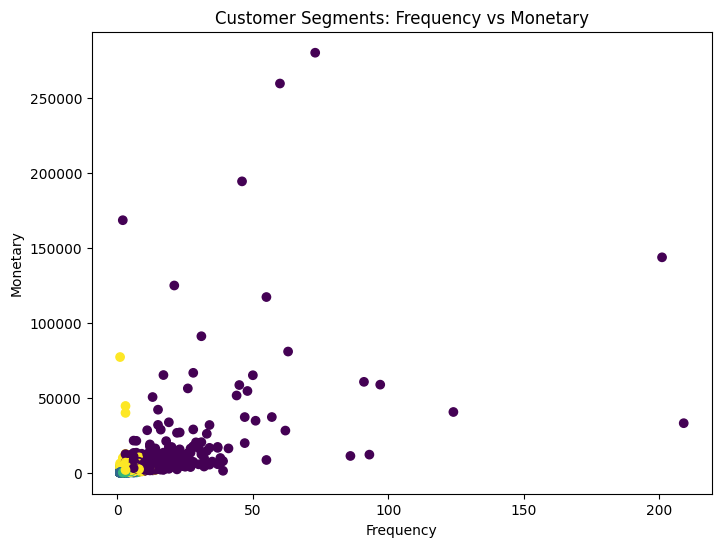

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Frequency vs Monetary')

plt.show()

In [48]:
segment_names = {
    0: 'Champions',
    1: 'At-Risk Customers',
    2: 'Potential Customers',
    3: 'Regular Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

In [49]:
rfm['Segment'].value_counts()

Segment
At-Risk Customers      1622
Regular Customers      1166
Potential Customers     837
Champions               713
Name: count, dtype: int64

In [50]:
final_summary = rfm.groupby('Segment').agg(
    Customers=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

final_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk Customers,1622,181.51,1.32,341.00
Champions,713,12.17,13.75,8088.02
Potential Customers,837,17.70,2.19,557.32
Regular Customers,1166,71.64,4.08,1801.78


In [51]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,3,Regular Customers
12347,2,7,4310.00,0,Champions
12348,75,4,1797.24,3,Regular Customers
12349,19,1,1757.55,2,Potential Customers
12350,310,1,334.40,1,At-Risk Customers


In [52]:
rfm.shape

(4338, 5)

In [53]:
final_customer_data = rfm.drop(columns=['Cluster']).reset_index()

final_customer_data.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,326,1,77183.60,Regular Customers
1,12347,2,7,4310.00,Champions
2,12348,75,4,1797.24,Regular Customers
3,12349,19,1,1757.55,Potential Customers
4,12350,310,1,334.40,At-Risk Customers


In [54]:
final_customer_data.shape

(4338, 5)

In [55]:
final_customer_data.to_csv(
    'customer_segmentation.csv',
    index=False
)

In [56]:
import os

os.path.exists('customer_segmentation.csv')

True

In [57]:
segment_summary = final_summary.reset_index()

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At-Risk Customers,1622,181.51,1.32,341.00
1,Champions,713,12.17,13.75,8088.02
2,Potential Customers,837,17.70,2.19,557.32
3,Regular Customers,1166,71.64,4.08,1801.78


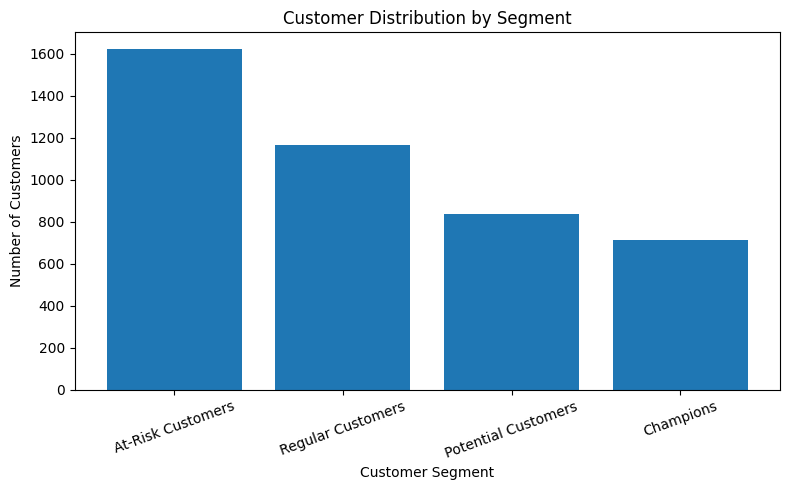

In [58]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Segment')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()